# 04 — Carbon-Relevance Dataset (V1.5)

Builds a spatially-informed carbon feature layer by combining:
1. CORINE land cover (from V1 features)
2. ESA CCI Biomass (if downloaded)
3. Soil/peat data (Estonian WFS: maardlad + ETAK wetlands)
4. Hydrology (ETAK: streams, ditches, waterbodies)

Outputs per-cell carbon scores that the simulator uses for more accurate CO₂ estimates.

**Run order:** This notebook replaces running the numbered scripts in `src/carbon_dataset/` manually.

In [1]:
import sys
from pathlib import Path

# Add carbon_dataset to path so we can import its modules
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src" / "carbon_dataset"))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import DATA_PROCESSED_CARBON, CRS

DATA_PROCESSED_CARBON.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {DATA_PROCESSED_CARBON}")

Output dir: C:\Users\risto\projects\et-landuse-neuroevolution\data\processed\carbon_v1_5


## Step 1 — Prepare grid

In [2]:
from config import BASE_GRID_PATH

grid_path = DATA_PROCESSED_CARBON / "grid.gpkg"

if grid_path.exists():
    grid = gpd.read_file(grid_path)
    print(f"Grid already exists: {len(grid)} cells")
else:
    grid = gpd.read_file(BASE_GRID_PATH)
    if grid.crs is None or grid.crs.to_epsg() != 3301:
        grid = grid.to_crs(CRS)
    if "cell_id" not in grid.columns:
        grid["cell_id"] = range(len(grid))
    grid["area_m2"] = grid.geometry.area
    grid.to_file(grid_path, driver="GPKG")
    print(f"Created grid: {len(grid)} cells")

print(f"Bounds: {grid.total_bounds}")
print(f"CRS: {grid.crs}")

Grid already exists: 2806 cells
Bounds: [ 446000. 6488000.  512000. 6575000.]
CRS: EPSG:3301


## Step 2 — CORINE features (from V1)

In [3]:
from importlib.util import spec_from_file_location, module_from_spec

corine_path = DATA_PROCESSED_CARBON / "corine_features.parquet"

if corine_path.exists():
    corine_df = pd.read_parquet(corine_path)
    print(f"CORINE features loaded: {len(corine_df)} cells")
else:
    # Import the fast adapter that derives from V1 features
    _spec = spec_from_file_location("corine_v1", PROJECT_ROOT / "src" / "carbon_dataset" / "02a_corine_from_v1.py")
    _mod = module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    
    v1_path = PROJECT_ROOT / "data" / "processed" / "v1" / "features_v1.parquet"
    corine_df = _mod.corine_from_v1(str(v1_path))
    _mod.save_corine_features(corine_df)

corine_df.head()

CORINE features loaded: 2806 cells


,cell_id,urban_share,agriculture_share,grassland_share,forest_share,wetland_share,water_share,other_natural_share,clc_group,dominant_clc_code,dominant_clc_share,land_cover_carbon_lookup_score,naturalness_score,afforestation_base_suitability,wetland_base_suitability,urban_or_water_constraint
0,0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,water,523,1.00,0.0,0.00,0.0,0.0,True
1,1,0.0,0.0,0.0,0.0,0.0,1.00,0.00,water,523,1.00,0.0,0.00,0.0,0.0,True
2,2,0.0,0.0,0.0,0.0,0.0,1.00,0.00,water,523,1.00,0.0,0.00,0.0,0.0,True
3,3,0.0,0.0,0.0,0.0,0.0,1.00,0.00,water,523,1.00,0.0,0.00,0.0,0.0,True
4,4,0.0,0.0,0.0,0.0,0.0,0.99,0.01,water,523,0.99,0.4,0.65,0.3,0.3,True


In [4]:
# Quick CORINE summary
print("Group share means:")
share_cols = [c for c in corine_df.columns if c.endswith("_share")]
print(corine_df[share_cols].mean().sort_values(ascending=False).to_string())
print(f"\nUrban/water constrained: {corine_df['urban_or_water_constraint'].sum()} / {len(corine_df)}")

Group share means:
dominant_clc_share     0.760651
forest_share           0.513205
agriculture_share      0.149832
grassland_share        0.128766
water_share            0.101048
wetland_share          0.095481
urban_share            0.009372
other_natural_share    0.002295

Urban/water constrained: 295 / 2806


## Step 3 — ESA CCI Biomass (optional)

If you have the ESA CCI Biomass GeoTIFF in `data/raw/esa_cci_biomass/`, this step processes it.  
Otherwise it's skipped and the carbon model uses CORINE forest share as a rough proxy.

### How to download

1. Register (free) at https://catalogue.ceda.ac.uk/uuid/6429d1aafe1e43b9b414e4a5a7f8b903/
2. Click **Download** → navigate to `geotiff/2022/`
3. Download the tile covering Estonia — **`N60E020`** (covers 50–60°N, 20–30°E):
   ```
   N60E020_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2022-fv7.0.tif       ← AGB (biomass)
   N60E020_ESACCI-BIOMASS-L4-AGB_SD-MERGED-100m-2022-fv7.0.tif    ← uncertainty
   ```
4. Place both in `data/raw/esa_cci_biomass/`

**Why 2022?** Closest to CORINE 2018 while still being recent. 2024 also works.

**Tile naming:** files are tiled by 10°×10° blocks, named by their southwest corner.  
Estonia is at ~58°N, 24°E → tile `N60E020` covers it entirely.

In [5]:
from config import BIOMASS_DIR

biomass_path = DATA_PROCESSED_CARBON / "biomass_features.parquet"
biomass_df = None

if biomass_path.exists():
    biomass_df = pd.read_parquet(biomass_path)
    print(f"Biomass features loaded: {len(biomass_df)} cells")
elif BIOMASS_DIR.exists() and list(BIOMASS_DIR.glob("*.tif")):
    _spec = spec_from_file_location("biomass", PROJECT_ROOT / "src" / "carbon_dataset" / "03_process_biomass.py")
    _mod = module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    
    biomass_df = _mod.process_biomass(grid, corine_df)
    _mod.save_biomass_features(biomass_df)
else:
    print(f"No biomass data found in {BIOMASS_DIR}")
    print("Download ESA CCI Biomass AGB GeoTIFF and place it there to enable this step.")
    print("→ https://catalogue.ceda.ac.uk/ (search 'ESA CCI Biomass')")
    print("\nProceeding with CORINE-based fallback for forest carbon.")

Processing AGB raster: C:\Users\risto\projects\et-landuse-neuroevolution\data\raw\esa_cci_biomass\N60E020_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2022-fv7.0.tif
  Uncertainty raster: C:\Users\risto\projects\et-landuse-neuroevolution\data\raw\esa_cci_biomass\N60E020_ESACCI-BIOMASS-L4-AGB_SD-MERGED-100m-2022-fv7.0.tif
Processed 2806 cells
Saved: C:\Users\risto\projects\et-landuse-neuroevolution\data\processed\carbon_v1_5\biomass_features.parquet


## Step 4 — Soil / Peat

Fetches peat and wetland polygons from Estonian public WFS services:
- `ms:Turvas_levi` — peat deposit extent (maardlad)
- `ms:ta_kasutatav` — exploitable peat
- `ms:ta_rikutud` — damaged peatland
- `etak:e_306_margala_a/ka` — wetlands (Raba, Madalsoo, Roostik)
- `etak:e_307_turbavali_a` — peat extraction fields

⏱ Takes ~2 min (WFS downloads + spatial overlay)

In [6]:
soil_path = DATA_PROCESSED_CARBON / "soil_peat_features.parquet"

if soil_path.exists():
    soil_df = pd.read_parquet(soil_path)
    print(f"Soil/peat features loaded: {len(soil_df)} cells")
else:
    _spec = spec_from_file_location("soil_peat", PROJECT_ROOT / "src" / "carbon_dataset" / "04_process_soil_peat.py")
    _mod = module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    
    soil_df = _mod.process_soil_peat(grid)
    _mod.save_soil_peat_features(soil_df)

Soil/peat features loaded: 2806 cells


In [7]:
print("Peatland status distribution:")
print(soil_df["peatland_status"].value_counts().to_string())
print(f"\nCells with wetland overlap > 0: {(soil_df['wetland_mire_overlap_pct'] > 0).sum()}")
print(f"Cells with peat overlap > 0: {(soil_df['peat_overlap_pct'] > 0).sum()}")
print(f"\nMean soil_carbon_relevance_score: {soil_df['soil_carbon_relevance_score'].mean():.3f}")
print(f"Mean wetland_restoration_soil_score: {soil_df['wetland_restoration_soil_score'].mean():.3f}")

Peatland status distribution:
peatland_status
none                    2278
wetland_no_peat_data     498
damaged                   27
exploitable                3

Cells with wetland overlap > 0: 1566
Cells with peat overlap > 0: 1

Mean soil_carbon_relevance_score: 0.229
Mean wetland_restoration_soil_score: 0.162


## Step 5 — Hydrology

Fetches from ETAK WFS:
- Streams, rivers, and **ditches** (`Kraav`) — important drainage indicator
- Standing waterbodies (lakes, ponds)

Computes distances, densities, and hydrology restoration scores.

⏱ Takes ~3-5 min (large WFS download: ~93k stream features)

In [8]:
hydro_path = DATA_PROCESSED_CARBON / "hydrology_features.parquet"

if hydro_path.exists():
    hydro_df = pd.read_parquet(hydro_path)
    print(f"Hydrology features loaded: {len(hydro_df)} cells")
else:
    _spec = spec_from_file_location("hydrology", PROJECT_ROOT / "src" / "carbon_dataset" / "05_process_hydrology.py")
    _mod = module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    
    hydro_df = _mod.process_hydrology(grid)
    _mod.save_hydrology_features(hydro_df)

Hydrology features loaded: 2806 cells


In [9]:
print("Hydrology summary:")
print(f"  Mean distance to water: {hydro_df['distance_to_water_m'].mean():.0f} m")
print(f"  Mean stream density: {hydro_df['stream_density_1km'].mean():.2f} km/cell")
print(f"  Mean ditch density: {hydro_df['ditch_density_1km'].mean():.2f} km/cell")
print(f"  Mean hydrology_restoration_score: {hydro_df['hydrology_restoration_score'].mean():.3f}")

Hydrology summary:
  Mean distance to water: 278 m
  Mean stream density: 0.30 km/cell
  Mean ditch density: 3.78 km/cell
  Mean hydrology_restoration_score: 0.698


## Step 6 — Derive combined carbon scores

In [10]:
_spec = spec_from_file_location("scores", PROJECT_ROOT / "src" / "carbon_dataset" / "06_derive_scores.py")
_mod = module_from_spec(_spec)
_spec.loader.exec_module(_mod)

carbon_scores = _mod.derive_carbon_scores(
    corine_df,
    biomass_df=biomass_df,
    soil_df=soil_df,
    hydrology_df=hydro_df,
)
_mod.save_carbon_scores(carbon_scores)

Derived carbon scores for 2806 cells
  Layers: CORINE=yes, Biomass=yes, Soil=yes, Hydrology=yes
  carbon_stock_score: mean=0.367, min=0.040, max=0.796
  protect_carbon_benefit: mean=0.254, min=0.000, max=0.627
  afforestation_carbon_potential: mean=0.131, min=0.000, max=0.700
  wetland_restoration_carbon_potential: mean=0.057, min=0.000, max=0.397
Saved: C:\Users\risto\projects\et-landuse-neuroevolution\data\processed\carbon_v1_5\carbon_scores.parquet


In [11]:
score_cols = [
    "carbon_stock_score",
    "protect_carbon_benefit",
    "afforestation_carbon_potential",
    "wetland_restoration_carbon_potential",
]
carbon_scores[score_cols].describe()

,carbon_stock_score,protect_carbon_benefit,afforestation_carbon_potential,wetland_restoration_carbon_potential
count,2806.000000,2806.000000,2806.000000,2806.000000
mean,0.367285,0.253555,0.130955,0.057179
std,0.188275,0.155148,0.199250,0.080063
min,0.040000,0.000000,0.000000,0.000000
25%,0.203351,0.109835,0.000000,0.016167
50%,0.389004,0.275174,0.016400,0.023483
75%,0.522500,0.383222,0.188157,0.038271
max,0.795952,0.626813,0.700000,0.396961


## Visualize carbon scores on the grid

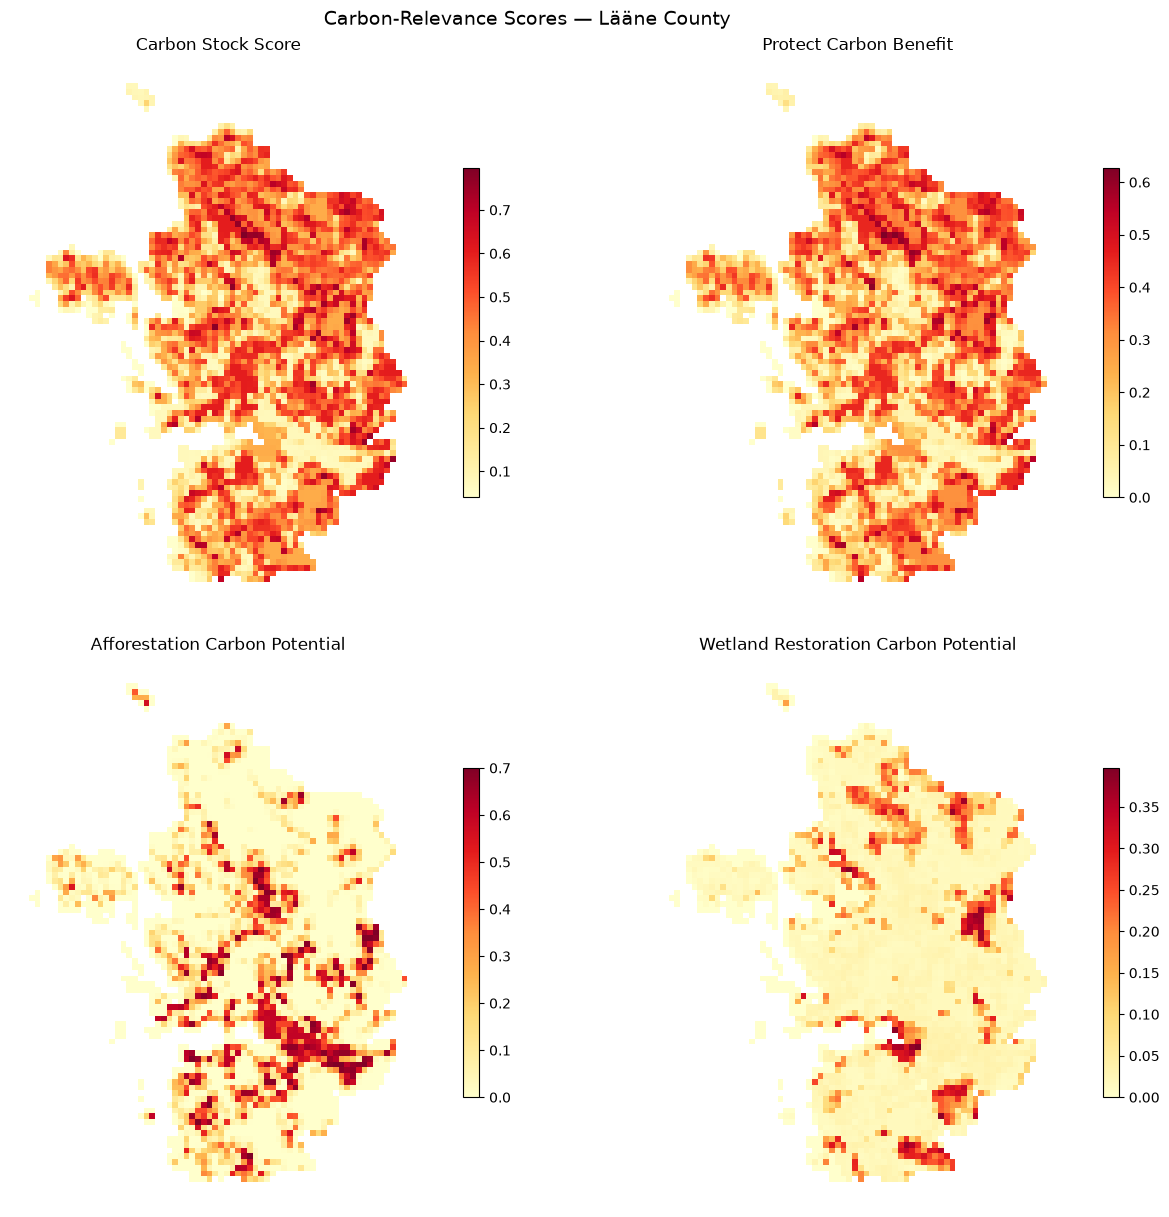

In [12]:
# Merge scores with grid geometry for mapping
grid_scores = grid[["cell_id", "geometry"]].merge(carbon_scores, on="cell_id")
grid_scores = gpd.GeoDataFrame(grid_scores, geometry="geometry", crs=CRS)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, col in zip(axes.flat, score_cols):
    grid_scores.plot(column=col, ax=ax, legend=True, cmap="YlOrRd",
                     legend_kwds={"shrink": 0.6})
    ax.set_title(col.replace("_", " ").title())
    ax.set_axis_off()

plt.tight_layout()
plt.suptitle("Carbon-Relevance Scores — Lääne County", y=1.01, fontsize=14)
plt.show()

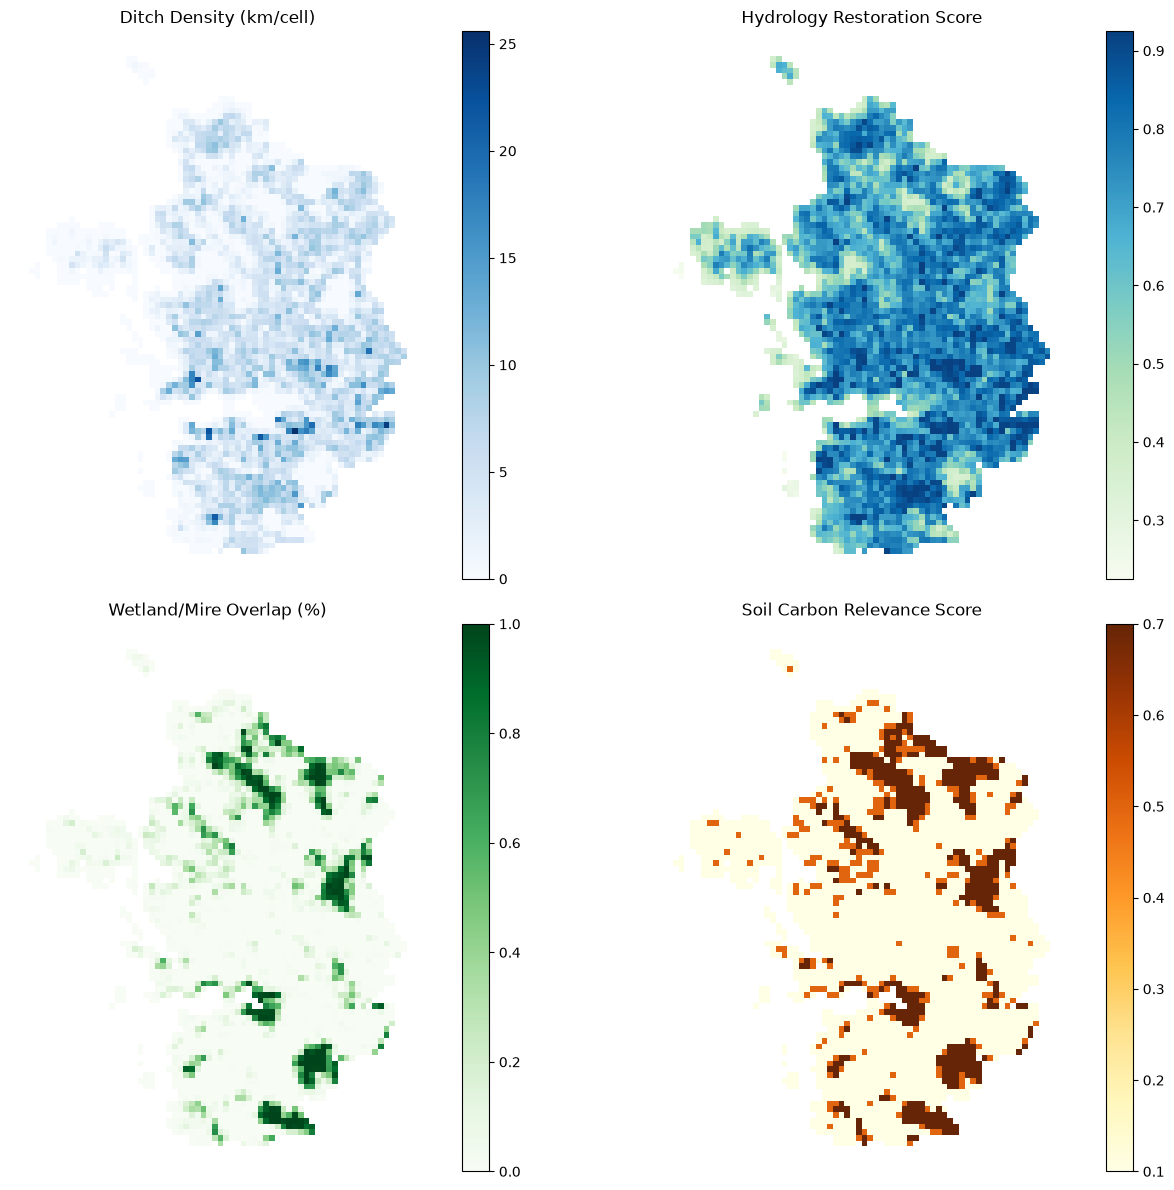

In [13]:
# Hydrology and soil detail maps
grid_hydro = grid[["cell_id", "geometry"]].merge(hydro_df, on="cell_id")
grid_hydro = gpd.GeoDataFrame(grid_hydro, geometry="geometry", crs=CRS)

grid_soil = grid[["cell_id", "geometry"]].merge(soil_df, on="cell_id")
grid_soil = gpd.GeoDataFrame(grid_soil, geometry="geometry", crs=CRS)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

grid_hydro.plot(column="ditch_density_1km", ax=axes[0, 0], legend=True, cmap="Blues")
axes[0, 0].set_title("Ditch Density (km/cell)")
axes[0, 0].set_axis_off()

grid_hydro.plot(column="hydrology_restoration_score", ax=axes[0, 1], legend=True, cmap="GnBu")
axes[0, 1].set_title("Hydrology Restoration Score")
axes[0, 1].set_axis_off()

grid_soil.plot(column="wetland_mire_overlap_pct", ax=axes[1, 0], legend=True, cmap="Greens")
axes[1, 0].set_title("Wetland/Mire Overlap (%)")
axes[1, 0].set_axis_off()

grid_soil.plot(column="soil_carbon_relevance_score", ax=axes[1, 1], legend=True, cmap="YlOrBr")
axes[1, 1].set_title("Soil Carbon Relevance Score")
axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

## Test simulator integration

Verify the simulator uses the new per-cell carbon scores.

In [14]:
from estonia_landuse.data.load import merge_carbon_v15
from estonia_landuse.simulator.features import derive_features
from estonia_landuse.simulator.simulator import summarize_policy
from estonia_landuse.simulator.config import default_config

# Load V1 features and merge carbon v1.5
v1_features = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "v1" / "features_v1.parquet")
derived = derive_features(v1_features)
merged = merge_carbon_v15(derived)

print(f"Features: {len(merged.columns)} columns")
print(f"Carbon v1.5 columns present: {'carbon_stock_score' in merged.columns}")

Features: 28 columns
Carbon v1.5 columns present: True


In [15]:
# Simple policy: shift 5% to forest, 2% to wetland, reduce agriculture
n = len(merged)
targets = np.column_stack([
    merged["forest_pct"].values + 0.05,
    merged["wetland_pct"].values + 0.02,
    merged["agriculture_pct"].values - 0.05,
    merged["grassland_pct"].values - 0.02,
])
targets = np.clip(targets, 0, 1)

# Compare old vs new carbon model
results_v15 = summarize_policy(merged, targets)

cfg_old = default_config()
cfg_old["carbon_v1_5"]["enabled"] = False
results_old = summarize_policy(merged, targets, config=cfg_old)

print("Policy: +5% forest, +2% wetland, -5% agriculture, -2% grassland")
print(f"{'Metric':<25} {'V1.5 carbon':>12} {'Old flat':>12} {'Diff':>10}")
print("-" * 60)
for key in results_v15:
    v15 = results_v15[key]
    old = results_old[key]
    print(f"{key:<25} {v15:>12.4f} {old:>12.4f} {v15-old:>+10.4f}")

Policy: +5% forest, +2% wetland, -5% agriculture, -2% grassland
Metric                     V1.5 carbon     Old flat       Diff
------------------------------------------------------------
biodiversity_gain               0.0157       0.0157    +0.0000
carbon_gain                     0.0313       0.0178    +0.0135
cost                            0.1250       0.1250    +0.0000
constraint_penalty              1.5695       1.5695    +0.0000
changed_pct                     0.0645       0.0645    +0.0000


## Summary

The carbon v1.5 model is now active. Key differences from the old flat model:

- **Carbon gain is spatially informed**: afforestation in cells with high afforestation potential scores higher; wetland restoration in drained peatland scores higher.
- **Preservation is valued**: keeping high-carbon cells unchanged contributes positively.
- **Losses are penalized by carbon stock**: removing forest or wetland from high-stock cells is more costly.

### Data sources used
| Layer | Source | Features |
|-------|--------|----------|
| CORINE | Existing V1 raster extract | Group shares, naturalness |
| Soil/Peat | maardlad + ETAK WFS | 5,000+ wetland polygons, peat deposits |
| Hydrology | ETAK WFS | 93k streams (86k ditches), 5k waterbodies |
| Biomass | ESA CCI (if downloaded) | AGB per cell |

### Next steps
- Download ESA CCI Biomass → re-run this notebook
- Run neuroevolution with the enhanced carbon objective
- Visualize Pareto fronts comparing old vs new carbon model